In [4]:
import pandas as pd
path = "Ice_cream_selling_data.csv"
df = pd.read_csv(path)
print(df.head())

   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


<function matplotlib.pyplot.show(close=None, block=None)>

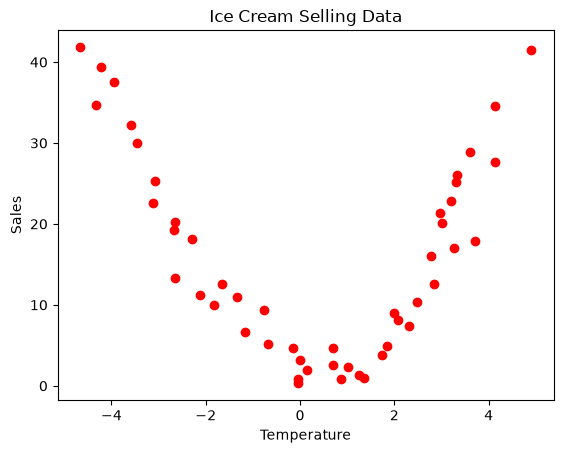

In [5]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
import matplotlib.pyplot as plt
plt.scatter(X, y, color = 'red')
plt.title('Ice Cream Selling Data')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show

Text(0.5, 1.0, 'Linear Regression')

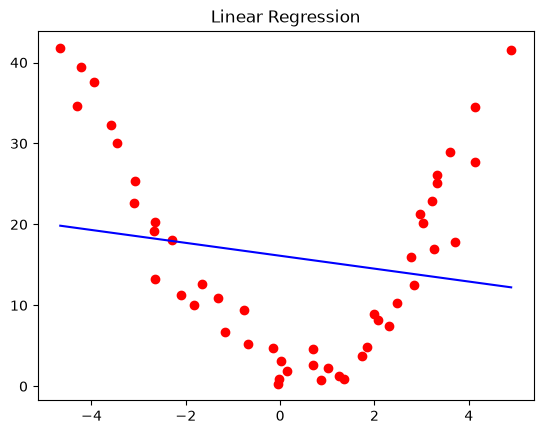

In [9]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X,y)
plt.scatter(X, y, color = 'red')
plt.plot(X, linear_model.predict(X), color = 'blue')
plt.title('Linear Regression')

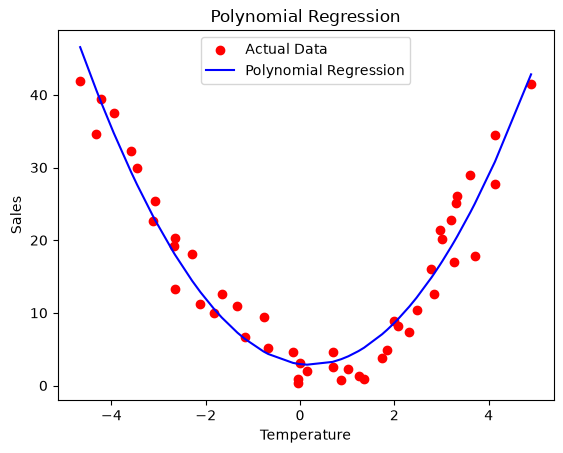

In [10]:
from sklearn.preprocessing import PolynomialFeatures
# Buat Polynomial Features
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)
# Buat model Linear Regression
linear_model2 = LinearRegression()
linear_model2.fit(X_poly, y) # Latih model dengan data polynomial
# Gunakan predict() untuk mendapatkan y_pred_poly
y_pred_poly = linear_model2.predict(X_poly)
# Plot Polynomial Regression
plt.scatter(X, y, color='red', label="Actual Data")
plt.plot(X, y_pred_poly, color='blue', label="Polynomial Regression")
plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [12]:
print('Intercept: ', linear_model2.intercept_)
print('Coefficient: ', linear_model2.coef_)
print('Equation: y = ',linear_model2.intercept_,'+',linear_model2.coef_[0],'x1, +',linear_model2.coef_[1],'x2')

Intercept:  2.9517741579934427
Coefficient:  [ 0.         -0.82468167  1.82952623]
Equation: y =  2.9517741579934427 + 0.0 x1, + -0.824681670210649 x2


In [13]:
dataset = pd.read_csv('manufacturing.csv')
print(dataset.head())

   Temperature (°C)  Pressure (kPa)  Temperature x Pressure  \
0        209.762701        8.050855             1688.769167   
1        243.037873       15.812068             3842.931469   
2        220.552675        7.843130             1729.823314   
3        208.976637       23.786089             4970.736918   
4        184.730960       15.797812             2918.345014   

   Material Fusion Metric  Material Transformation Metric  Quality Rating  
0            44522.217074                    9.229576e+06       99.999971  
1            63020.764997                    1.435537e+07       99.985703  
2            49125.950249                    1.072839e+07       99.999758  
3            57128.881547                    9.125702e+06       99.999975  
4            38068.201283                    6.303792e+06      100.000000  


In [14]:
X = dataset.iloc[:, 2:5].values
y = dataset.iloc[:, 5].values
X

array([[1.68876917e+03, 4.45222171e+04, 9.22957596e+06],
       [3.84293147e+03, 6.30207650e+04, 1.43553672e+07],
       [1.72982331e+03, 4.91259502e+04, 1.07283887e+07],
       ...,
       [3.95630467e+03, 6.26576910e+04, 1.40595745e+07],
       [4.97723476e+03, 5.71959855e+04, 9.13403620e+06],
       [3.97489712e+03, 4.10923929e+04, 4.35891253e+06]], shape=(3957, 3))

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)
linear_model2 = LinearRegression()
linear_model2.fit(X_train_poly, y_train)
y_pred = linear_model2.predict(X_test_poly)

In [17]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
score

0.6923518520550729

In [19]:
#Tugas
#Polynomial Regression Degree 1
poly_reg1 = PolynomialFeatures(degree=1)

X_train_poly1 = poly_reg1.fit_transform(X_train)
X_test_poly1 = poly_reg1.transform(X_test)
linear_model1 = LinearRegression()
linear_model1.fit(X_train_poly1, y_train)
y_pred1 = linear_model1.predict(X_test_poly1)
score1 = r2_score(y_test, y_pred1)
print("R-square Degree 1:", score1)

# Polynomial Regression Degree 3
poly_reg3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly_reg3.fit_transform(X_train)
X_test_poly3 = poly_reg3.transform(X_test)
linear_model3 = LinearRegression()
linear_model3.fit(X_train_poly3, y_train)
y_pred3 = linear_model3.predict(X_test_poly3)
score3 = r2_score(y_test, y_pred3)
print("R-square Degree 3:", score3)

# Polynomial Regression Degree 5
poly_reg5 = PolynomialFeatures(degree=5)
X_train_poly5 = poly_reg5.fit_transform(X_train)
X_test_poly5 = poly_reg5.transform(X_test)
linear_model5 = LinearRegression()
linear_model5.fit(X_train_poly5, y_train)
y_pred5 = linear_model5.predict(X_test_poly5)
score5 = r2_score(y_test, y_pred5)
print("R-square Degree 5:", score5)

R-square Degree 1: 0.4624884218411217
R-square Degree 3: 0.8049852390399241
R-square Degree 5: 0.9095053064574692
